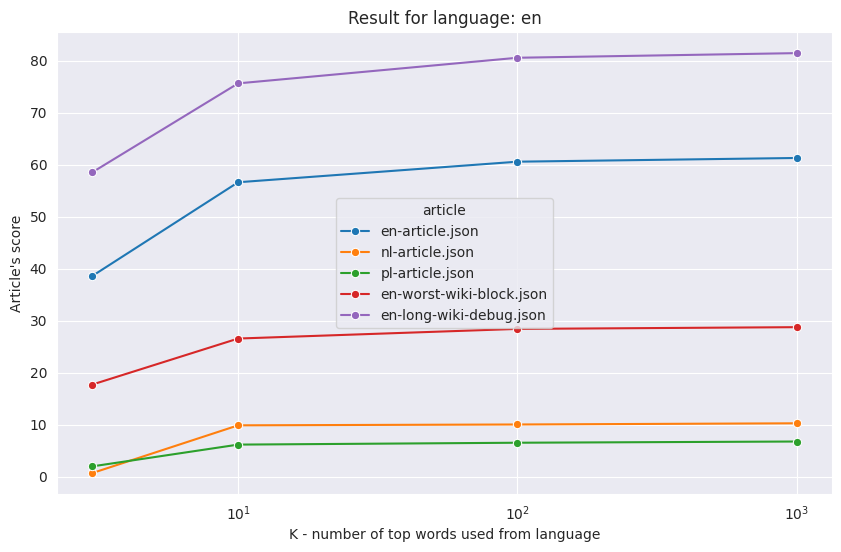

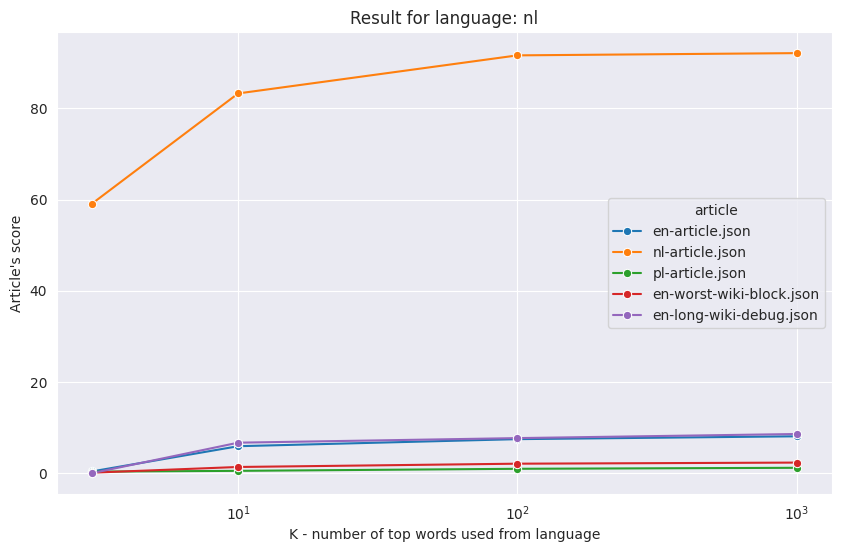

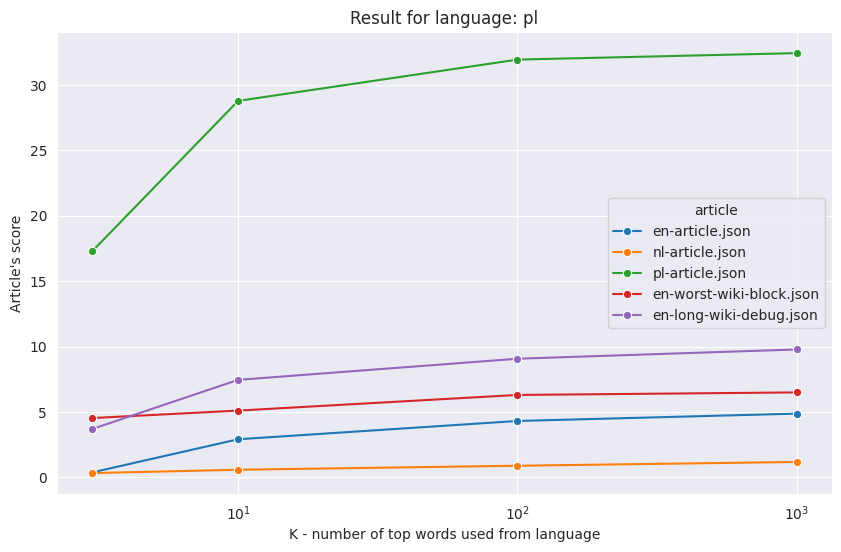

In [7]:
from wordfreq import word_frequency, top_n_list
from collections import Counter
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# preparing data
k_values = [3, 10, 100, 1000]
langs = ["en", "nl", "pl"]
art_files = ["en-article.json",
                 "nl-article.json",
                 "pl-article.json",
                 "en-worst-wiki-block.json",
                "en-long-wiki-debug.json"]

# dict for each language: word: word_frequency in this lanugage
top_words_data = {
    "en": {}, # english
    "pl": {}, # polish
    "nl": {} # dutch
}

for k in k_values:
    for lang in langs:
        top_words_data[lang][k] = {word: word_frequency(word=word, lang=lang)
                                   for word in top_n_list(lang=lang, n=k)}


def lang_confidence_score(word_counts, language_words_with_frequency):
    with open("analysis/" + word_counts, "r", encoding="utf-8") as file:
        text_counter = Counter(json.loads(file.read()))

    result = 0
    top_words = language_words_with_frequency.keys()
    for word, occurences in text_counter.items():
        if word in top_words:
            result += occurences * language_words_with_frequency[word]

    # normalisation (remove long articles' advantage)
    art_len = text_counter.total()

    return result / art_len * 10000
    # przemnozyc przez stala zeby bylo ladniej? i usunac po przecinku?
results = []

for k in k_values:
    for lang in langs:
        for art_file in art_files:
            score = lang_confidence_score(word_counts=art_file,
                                          language_words_with_frequency=top_words_data[lang][k])
            results.append({
                "k": k,
                "tested_lang": lang,
                "article": art_file,
                "score": score
            })

df = pd.DataFrame(results)

for lang, group in df.groupby("tested_lang"):
    plt.figure(figsize=(10, 6))
    plt.xscale('log')
    plt.grid(True)
    sns.lineplot(data=group, x="k", y="score", hue="article", marker="o")
    plt.title(f"Result for language: {lang}")
    plt.ylabel("Article's score")
    plt.xlabel("K - number of top words used from language")
    plt.show()

#### Wnioski
W każdym przypadku, po wykresie, na pierwszy rzut oka widać, że:
1. artykuł w badanym języku góruje
2. artykuły w innych językach osiągają podobne wyniki.
Tak więc uznaję funkcję za relatywnie dobrą. Warto jednak zwrócić uwagę na, odnotowane przy badaniu angielskiego, duże zróżnicowanie wyników "pozytywnych" próbek. Najgorszy artykuł z wiki, w sensie bezwzględnym, jest mniej więcej 2 razy bliższy artykułom w innych językach niż najlepszemu artykułowi z wiki.

---

###### Czy dobór języków miał duże znaczenie?
Tak i nie. Z jednej strony, gdybym wziął 2 bardzo podobne języki, to na pewno miałyby bardziej zbliżone wyniki (nawiasem mówiąc, zamiast holenderskiego chciałem wziąć fryzyjski, najpodobniejszy do angielskiego język, ale nie był dostępny w wordfreq). Też pytanie, co rozumiemy przez podobieństwo - języki moga mieć podobną gramatykę lub brzmienie, a nieznaczne różnice w sposobie zapisu kluczowych słów prowadzą do zupełnie różnych wyników przy metodzie operującej na częstotliwości słów.

---

######  Czy po wartościach language_words_with_frequency dla danych i najczęstszych słowach z języka danych widać, że w wybranym języku słowa często są odmieniane?
Po samych najczęstszych słowach na pewno nie - tzn. pytanie, ile najczęstszych badamy, bo np. w 20 najczęstszych w polskim nic nie sugeruje, że jest to język z bardzo bogatą odmianą. Jednak language_words_with_frequency pokazują znacznie więcej - gdy je posortujemy, możemy (znów na przykładzie polskiego) zobaczyć relatywnie niedaleko siebie te same słowa w różnych odmianach.

---

######  Czy trudne było znalezienie takiego artykułu, dla którego wynik language_words_with_frequency jest jak najmniejszy w języku wiki?
Tak i nie, na pewno był to ciekawy proces, który doprowadził mnie do (sic!) zamiany kandydatów na long i worst. Początkowo moim kandydatem na long był artykuł o blokach - po prostu długi artykuł o jednym z podstawowych pojęć w minecrafcie. By osiągnąć jak najgorszy wynik, szukałem krótkiego artykułu pełnego technicznego słownictwa. Wiele artykułów roiło się od linków do różnych wersji Minecrafta (a nawet konkretnych patchy, np. Java_Edition_Alpha_v1.1.2), więc to był oczywisty strzał. Jednak okazało się (po uwzględnieniu w funkcji długości artykułu), że worst przebija long! Wyjaśnienie nasuwa się samo - po uwzględnieniu proporcji, w długim tekście jest znacznie więcej specjalistycznego słownictwa, a mniej najwyżej punktowanych słów typu "a" czy "the". Kilka moich innych pomysłów osiągało wyniki gdzieś pomiędzy. W końcu stwierdziłem, że spróbuję jakiegoś jeszcze bardziej technicznego artykułu i wybrałem "debug". Jednak osiągnął wynik nie tylko wyższy niż "block", ale również wyższy niż tekst spoza wiki! Okazało się, że paradoksalnie znacznie więcej jest tam często używanych słów.

---

###### Czy to specyfika tego wiki?
Tak. Minecraft wiki zawiera dużo specyficznego słownictwa - od technicznego ("java", "gamemode", "xbox"), przez typowo związane z grami ("player", "keyboard", "equipment") aż po własne ("enderman", "herobrine"). Okazuje się, że poziom stężenia tych słów, którego wysokość zaniża wynik, wcale nie jest tak prosty do oszacowania.